In [2]:
!pip install wordcloud

# Carga de dataset y librerias

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [10]:
df = pd.read_csv('Reviews.csv')
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 327285 entries, 0 to 327284
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Id                      327285 non-null  int64  
 1   ProductId               327285 non-null  object 
 2   UserId                  327285 non-null  object 
 3   ProfileName             327269 non-null  object 
 4   HelpfulnessNumerator    327285 non-null  float64
 5   HelpfulnessDenominator  327285 non-null  float64
 6   Score                   327285 non-null  float64
 7   Time                    327285 non-null  float64
 8   Summary                 327272 non-null  object 
 9   Text                    327285 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 27.5+ MB


In [15]:
df.dropna(subset= ['Text', 'Score'], inplace = True)

# Creación de WordCloud para cada valor de score

El dataset elegido tiene reseñas a comidas de Amazon con puntaje incluido, registradas a lo largo de 10 años, empezando desde el 2012

In [17]:
df['Score'].unique()

array([5., 1., 4., 2., 3.])

Hay solo 5 tipos diferentes de valores para el puntaje dado a una reseña. Para observar las palabras más usadas en cada puntaje se creará un wordcloud para cada uno de los puntajes

In [18]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

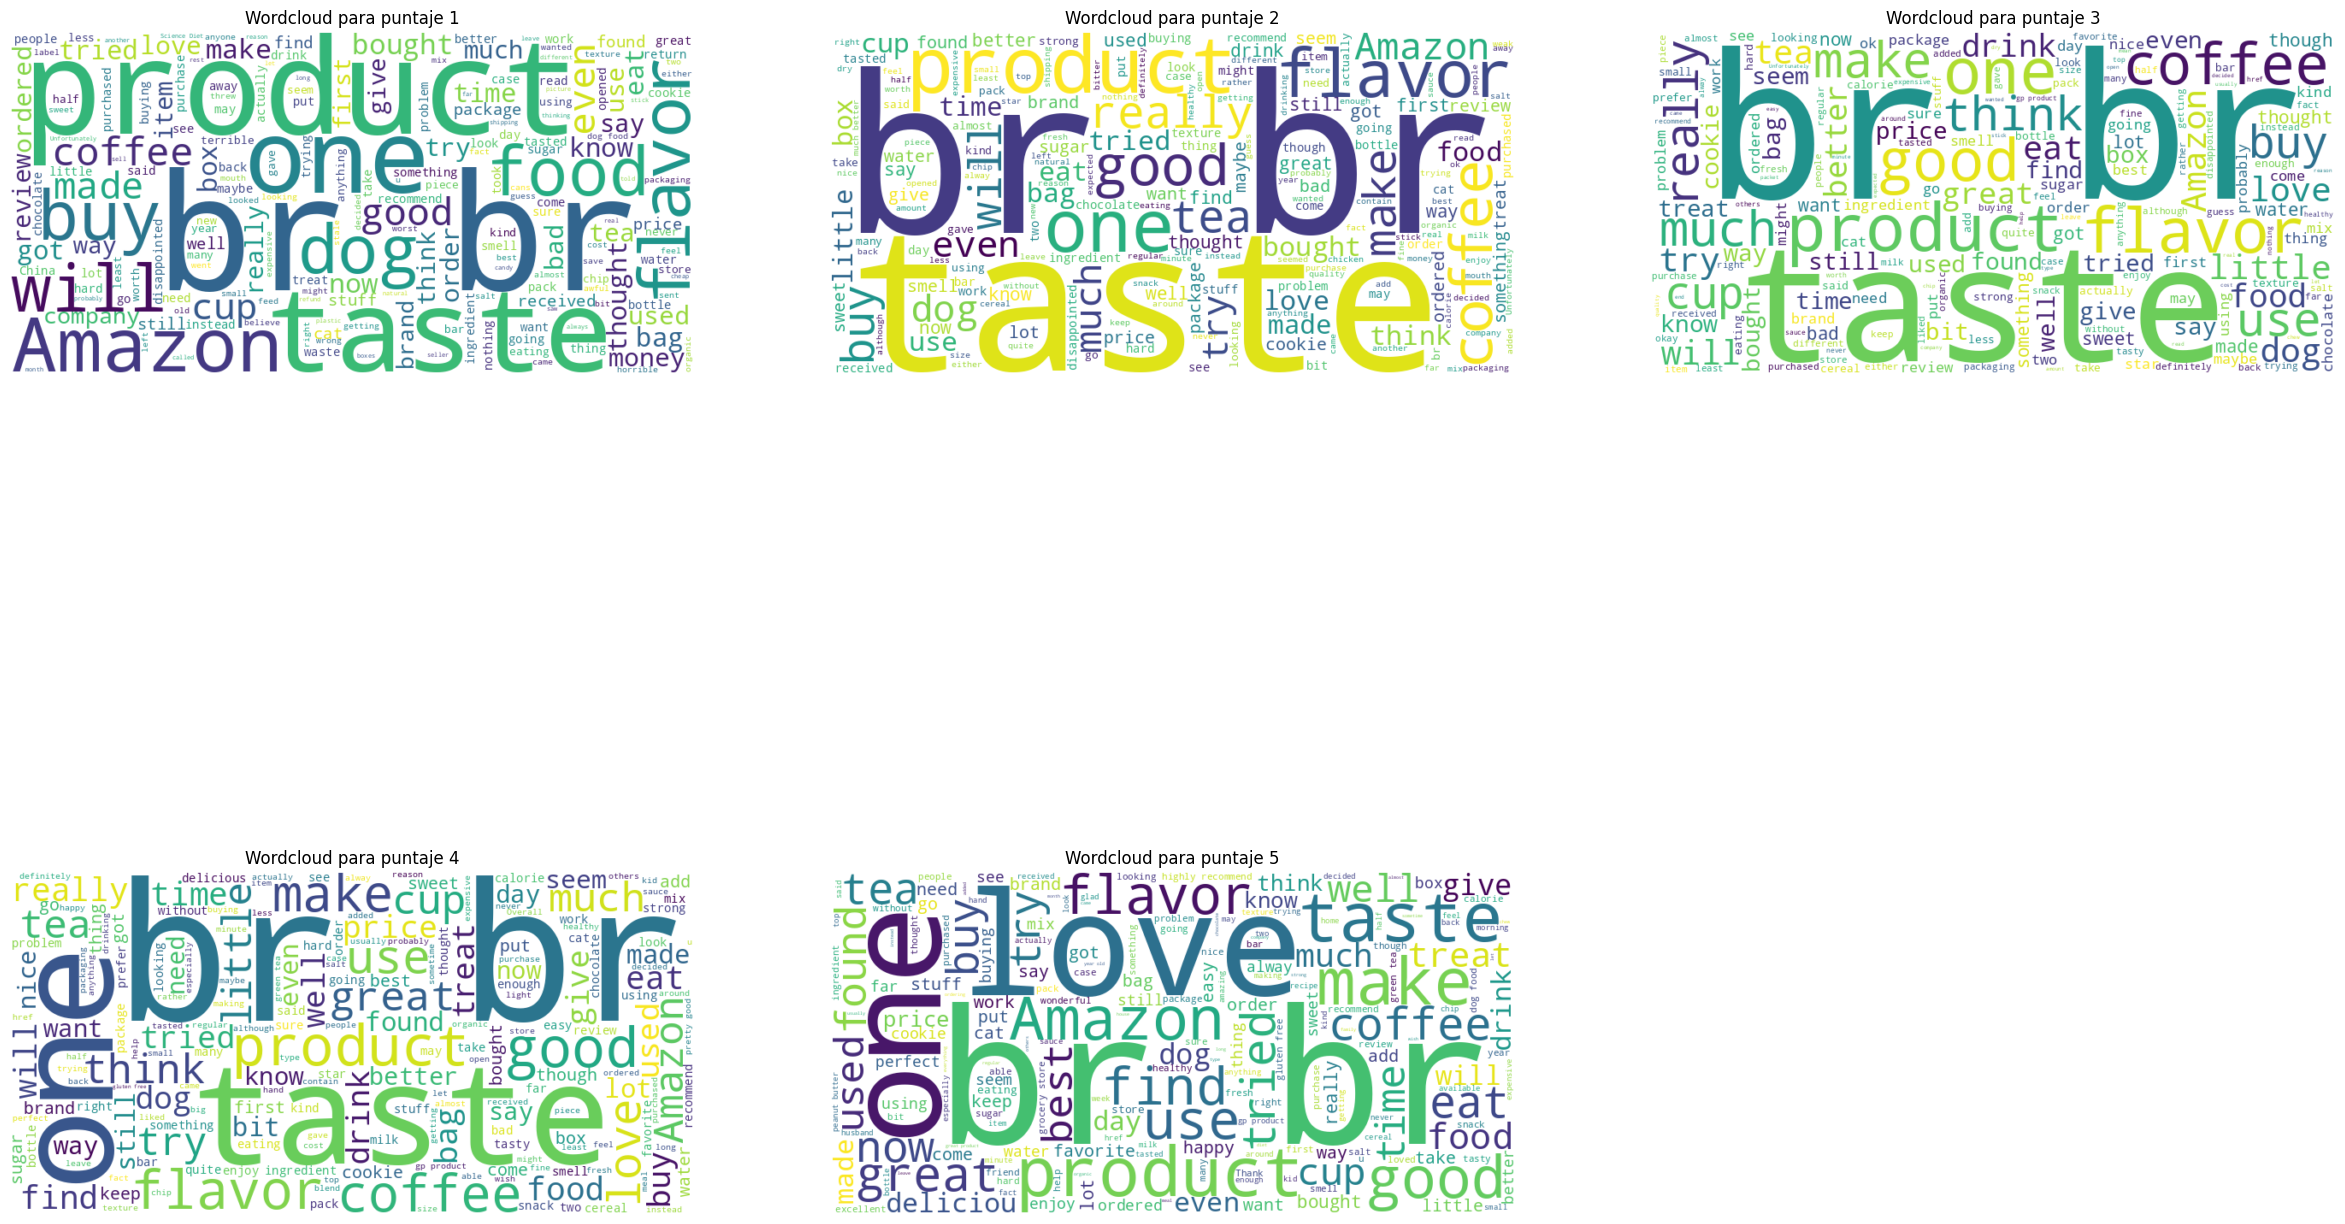

In [20]:
plt.figure(figsize=(30, 20))

for i in range(1,6):

  df_score = df[df['Score'] == i]

  text = " ".join(df_score["Text"])


  cloud = WordCloud(
      width=800,
      height=400,
      background_color="white",
      colormap="viridis"
  ).generate(text)

  plt.subplot(2, 3, i)
  plt.imshow(cloud, interpolation="bilinear")
  plt.title(f"Wordcloud para puntaje {i}")

  plt.axis("off")

Para empezar, en todas se repiten las palabras br mucho, ya que estás son palabras claves utilizadas para indicar un salto de línea.

Por otro lado, en todas se repiten muchas palabras relacionadas a la comida:  "flavor", "taste" o "food", lo cual corrabora el hecho de que el dataset utilizada es sobre reseñas de comidas. Además, el café parece ser un producto muy comprado o reseñado dentro del dataset, al destacar en todos los tipos de puntuación. Esto puede indicar que usualemente se compra café online, si es que los datos fueron obtenidos de forma aleatoria.

Lo primero a resaltar de los resultados es observar que cuando el puntaje es de 5, sí hay palabras muy frecuentes relacionadas a una puntuación alta como "love", "good" o "great"; además que suelen ser más frecuentes en opiniones con puntuaciones altas que en puntuaciones bajas.

En contraste, la nube de palabras para las reseñas con la peor puntuación, 1, destaca la palabra "will", "buy" y "Amazon" en comparación con las demás nubes. La primera y segunda palabras pueden indicar que muchas veces que el producto era malo, el consumidor se ve obligado a hacer una acción aparte, como devoluciones, quejas o directamente decir que no compraría de nuevo el producto. La tercera palabra, "Amazon", puede indicar que muchas de las quejas iban dirigidas a Amazon, o sea problemas directamente con la entrega de productos, que es en sí el trabajo de Amazon. Por último, la palabra "dog" destaca de entre las demás, indicando las siguientes dos cosas: Hubo problemas con los perros de los dueños al momento de ingerir la comida, o dentro del dataset se incluye la venta de comida de perro, la cual suele ser mal evaluada.

